<a href="https://colab.research.google.com/github/Glaze0/Assignment/blob/main/12_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression — Star Health Premium Pricing
**Question:** how much will a new applicant cost Star Health in medical claims next year, so we can price their premium?

## 0. The Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
!gdown 1nBNY8uePbDqcLQlKXyLFlnOMTKpB3mSS

Downloading...
From: https://drive.google.com/uc?id=1nBNY8uePbDqcLQlKXyLFlnOMTKpB3mSS
To: /content/insurance.csv
100% 54.3k/54.3k [00:00<00:00, 83.0MB/s]


In [ ]:
insurance = pd.read_csv("insurance.csv")
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## EDAAAAAAAAAAA..
analysis.
- info()
- duplicates
- outliers
- feature distribution
- describe()
- missing values (impute)
- etc.


In [ ]:
insurance[insurance.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [ ]:
insurance = insurance.drop_duplicates()

In [ ]:
insurance.shape

(1337, 7)

In [ ]:
insurance.describe().round(1)

,age,bmi,children,charges
count,1337.0,1337.0,1337.0,1337.0
mean,39.2,30.7,1.1,13279.1
std,14.0,6.1,1.2,12110.4
min,18.0,16.0,0.0,1121.9
25%,27.0,26.3,0.0,4746.3
50%,39.0,30.4,1.0,9386.2
75%,51.0,34.7,2.0,16657.7
max,64.0,53.1,5.0,63770.4


In [ ]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
data = pd.get_dummies(insurance, drop_first=True, dtype=int)
data.shape

(1337, 9)

In [ ]:
data.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


Never ever scale on output column.
- age : 18-64
- bmi : 15-45

In [ ]:
X = data.drop(columns="charges")
y = data["charges"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X_train), len(X_test)

(1069, 268)

## 1. Baseline: Predict the Average

In [ ]:
average = y_train.mean()
print(average)

13030.203369289055


In [ ]:
y_pred = [13030] * len(y_test)

# MAE
mean_absolute_error(y_test, y_pred)

9861.797880026175

In [ ]:
print(y_test[:5].values)
print(y_pred[:5])

[ 8688.85885  5708.867   11436.73815 38746.3551   4463.2051 ]
[np.float64(13030.203369289055), np.float64(13030.203369289055), np.float64(13030.203369289055), np.float64(13030.203369289055), np.float64(13030.203369289055)]


## 2. Simple Linear Regression: One Feature

In [ ]:
data.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [ ]:
from sklearn.preprocessing import StandardScaler as STD

scaler = STD()    #Standardization ofnumerical values
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
age_model = LinearRegression()
age_model.fit(X_train[["age"]], y_train)

LinearRegression()

In [ ]:
X_train[["age", "bmi"]].head()

,age,bmi
1114,23,24.510
968,21,25.745
599,52,37.525
170,63,41.470
275,47,26.600


In [ ]:
X_train["age", "bmi"]

KeyError: ('age', 'bmi')

In [ ]:
print("Intercept (w0):", round(age_model.intercept_))
print("Slope (w1):    ", round(age_model.coef_[0]))

Intercept (w0): 3534
Slope (w1):     242


In [ ]:
# y^ = 242*age + 3534

In [ ]:
y_pred = age_model.predict( X_test[['age']] )

mean_absolute_error(y_test, y_pred)

9657.78934976123

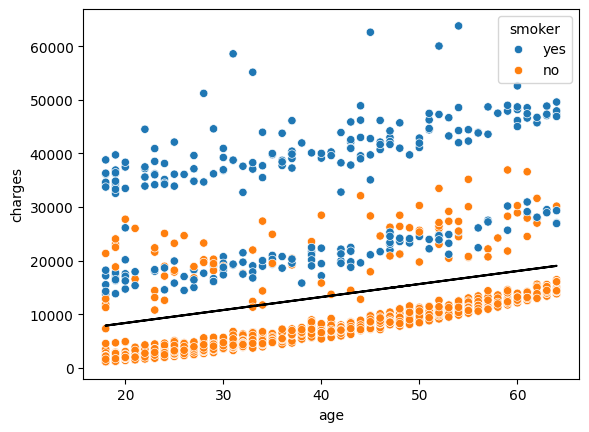

In [ ]:
sns.scatterplot(data=insurance, x="age", y="charges", hue="smoker")
plt.plot(X_test["age"], y_pred, color="black")
plt.show()

Two lines: A has residuals +100, −100; B has residuals +150, 0. Which one does least squares prefer?

In [ ]:
(100**2 + 100**2)/2

10000.0

In [ ]:
(150**2 + 0**2)/2

11250.0

## 3. How the Line Is Chosen: Least Squares

In [ ]:
residuals = y_train - age_model.predict(X_train[["age"]])
residuals.head()

,charges
1114,-6709.933327
968,-5341.644373
599,17340.456258
170,-5390.965003
275,-5204.383872


In [ ]:
# Sum of squared errors (SSE) for the fitted line, (in million)
(residuals ** 2).mean() / 1e6

np.float64(125.42469250155416)

In [ ]:
# Any other line has a larger SSE -- try a steeper slope
steeper = age_model.intercept_ + 300 * X_train["age"]
((y_train - steeper) ** 2).sum() / 1e6

np.float64(140253.1649360187)

Q - Why not just add up the raw residuals?

A - we don't want residuals to cancel out.



## 4. Multiple Linear Regression: All Features

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

print(model.coef_)

[  248.21072022   318.70144095   533.0099888   -101.54205399
 23077.76459287  -391.76145478  -838.91961573  -659.13975155]


In [ ]:
model.intercept_

np.float64(-11092.65229594595)

In [ ]:
pd.Series(model.coef_, index=X_train.columns).round()

,0
age,248.0
bmi,319.0
children,533.0
sex_male,-102.0
smoker_yes,23078.0
region_northwest,-392.0
region_southeast,-839.0
region_southwest,-659.0


In [ ]:
y_pred = model.predict(X_test)
y_pred[:5]

array([ 8143.69388412,  5737.11568259, 14369.31487618, 31745.51363586,
        8962.38665706])

In [ ]:
mean_absolute_error(y_test, y_pred)

4177.045561036319

## 5. Evaluation Metrics: MAE, RMSE, R²

In [ ]:
y_pred = model.predict(X_test)

print("MAE :", round(mean_absolute_error(y_test, y_pred)))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred))))

# R2 score.
print("R²  :", round(r2_score(y_test, y_pred), 2))

MAE : 4177
RMSE: 5956
R²  : 0.81


In [ ]:
y_train.mean()

np.float64(13030.203369289055)

In [ ]:
y_test.mean() # never doo this.. ( data leakage )

np.float64(14272.007559287313)

In [ ]:
# Avg error = ((y_test - 13030)**2).mean()

np.float64(185298646.8184262)

In [ ]:
# R2 : 1 - (model's SSE / SSE of always predicting the average)
sse_model = ((y_test - y_pred) ** 2).mean()
sse_average = ((y_test - 13030) ** 2).mean()
r2 = 1 - sse_model / sse_average
round(r2, 2)

np.float64(0.81)

In [ ]:
y_pred = model.predict(X_test).round(2)
y_pred[:5]

array([ 8143.69,  5737.12, 14369.31, 31745.51,  8962.39])

## 6. Residuals: What Is the Model Missing?

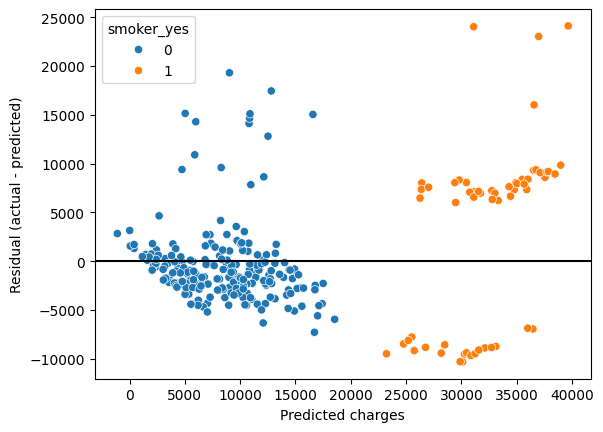

In [ ]:
residuals = y_test - y_pred

sns.scatterplot(x=y_pred, y=residuals, hue=X_test["smoker_yes"])
plt.axhline(0, color="black")
plt.xlabel("Predicted charges")
plt.ylabel("Residual (actual - predicted)")
plt.show()

<Axes: xlabel='charges', ylabel='Count'>

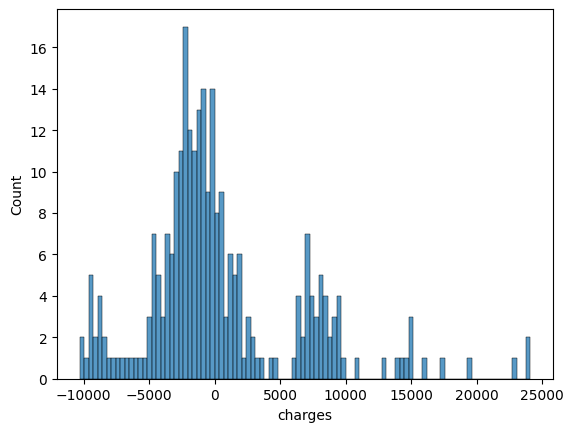

In [ ]:
sns.histplot(residuals, bins=100)

In [ ]:
# Smokers: split by obesity (BMI >= 30)
residuals.groupby([X_test["smoker_yes"], X_test["bmi"] >= 30]).mean().round()

## 7. Fix It With One Feature

In [ ]:
X_traizn["smoker_yes"] * (X_train["bmi"] >= 30).astype(int)

,0
1114,0
968,0
599,0
170,0
275,0
...,...
1096,1
1131,0
1295,0
861,0


In [ ]:
X_train["obese_smoker"] = X_train["smoker_yes"] * (X_train["bmi"] >= 30).astype(int)
X_test["obese_smoker"] = X_test["smoker_yes"] * (X_test["bmi"] >= 30).astype(int)

In [ ]:
X_train.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,obese_smoker
1114,23,24.510,0,1,0,0,0,0,0
968,21,25.745,2,1,0,0,0,0,0
599,52,37.525,2,0,0,1,0,0,0
170,63,41.470,0,1,0,0,1,0,0
275,47,26.600,2,0,0,0,0,0,0


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train) # newly feature created.
y_pred = model.predict(X_test)

print("MAE :", round(mean_absolute_error(y_test, y_pred)))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred))))
print("R²  :", round(r2_score(y_test, y_pred), 2))

MAE : 2392
RMSE: 4163
R²  : 0.91


In [ ]:
pd.Series(model.coef_, index=X_train.columns).round()

,0
age,259.0
bmi,49.0
children,559.0
sex_male,-476.0
smoker_yes,13292.0
region_northwest,-144.0
region_southeast,-562.0
region_southwest,-1118.0
obese_smoker,19455.0


## 8. Pricing New Applicants

In [ ]:
applicants = pd.DataFrame({
    "age":              [25, 45, 45],
    "bmi":              [24, 33, 33],
    "children":         [0, 2, 2],
    "sex_male":         [1, 0, 0],
    "smoker_yes":       [0, 0, 1],
    "region_northwest": [0, 0, 0],
    "region_southeast": [1, 1, 1],
    "region_southwest": [0, 0, 0],
    "obese_smoker":     [0, 0, 1],
})
applicants

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,obese_smoker
0,25,24,0,1,0,0,1,0,0
1,45,33,2,0,0,0,1,0,0
2,45,33,2,0,1,0,1,0,1


In [ ]:
model.predict(applicants).round()

array([ 3485., 10705., 43452.])